In [8]:
# ============================================================
# CELL 1: Imports and Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load clean transactions
df = pd.read_csv(
    '../data/processed/clean_transactions.csv',
    parse_dates=['InvoiceDate'],
    dtype={'Customer ID': str}
)

# Load cancellations — we'll use these for return rate feature
cancellations = pd.read_csv(
    '../data/processed/cancellations.csv',
    parse_dates=['InvoiceDate'],
    dtype={'Customer ID': str}
)

# Snapshot date = the day AFTER the last transaction
# Why: We calculate recency as "days before this date"
# Using max date + 1 day is standard practice so the most
# recent customer doesn't get recency = 0
SNAPSHOT_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Transactions loaded:  {len(df):,}")
print(f"Cancellations loaded: {len(cancellations):,}")
print(f"Snapshot date:        {SNAPSHOT_DATE.date()}")
print(f"Unique customers:     {df['Customer ID'].nunique():,}")

Transactions loaded:  779,425
Cancellations loaded: 19,104
Snapshot date:        2011-12-10
Unique customers:     5,878


In [9]:
# ============================================================
# CELL 2: RFM Features — The Foundation
# ============================================================
# RFM stands for:
#   Recency   — How recently did the customer buy?
#   Frequency — How often do they buy?
#   Monetary  — How much do they spend?
#
# Why RFM? It's been used in direct marketing since the 1980s.
# It's simple, interpretable, and proven to predict customer value.
# Any business stakeholder immediately understands it.

rfm = df.groupby('Customer ID').agg(
    # Recency: days since last purchase
    # Lower = better (bought more recently)
    Recency=('InvoiceDate', lambda x: (SNAPSHOT_DATE - x.max()).days),

    # Frequency: number of unique invoices (orders)
    # Higher = better (buys more often)
    Frequency=('Invoice', 'nunique'),

    # Monetary: total spend
    # Higher = better (spends more)
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM Features Created:")
print(f"  Recency   — min: {rfm['Recency'].min()} days, max: {rfm['Recency'].max()} days, median: {rfm['Recency'].median():.0f} days")
print(f"  Frequency — min: {rfm['Frequency'].min()}, max: {rfm['Frequency'].max()}, median: {rfm['Frequency'].median():.0f} orders")
print(f"  Monetary  — min: £{rfm['Monetary'].min():.0f}, max: £{rfm['Monetary'].max():,.0f}, median: £{rfm['Monetary'].median():.0f}")
print(f"\nRFM table shape: {rfm.shape}")
rfm.head(3)

RFM Features Created:
  Recency   — min: 1 days, max: 739 days, median: 96 days
  Frequency — min: 1, max: 398, median: 3 orders
  Monetary  — min: £3, max: £580,987, median: £868

RFM table shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40


In [10]:
# ============================================================
# CELL 3: Behavioral Features
# ============================================================
# These go BEYOND standard RFM and show modeling sophistication

# --- Average Order Value ---
# Why: Distinguishes bulk buyers (high AOV, low frequency)
# from frequent small buyers (low AOV, high frequency)
aov = df.groupby(['Customer ID', 'Invoice'])['TotalPrice'].sum().reset_index()
aov = aov.groupby('Customer ID')['TotalPrice'].mean().reset_index()
aov.columns = ['Customer ID', 'AvgOrderValue']

# --- Average Basket Size (items per order) ---
# Why: Large baskets = wholesale/bulk buyer behavior
basket = df.groupby(['Customer ID', 'Invoice'])['Quantity'].sum().reset_index()
basket = basket.groupby('Customer ID')['Quantity'].mean().reset_index()
basket.columns = ['Customer ID', 'AvgBasketSize']

# --- Unique Products Purchased ---
# Why: Breadth of shopping = customer engagement depth
product_diversity = df.groupby('Customer ID')['StockCode'].nunique().reset_index()
product_diversity.columns = ['Customer ID', 'UniqueProducts']

# --- Return Rate ---
# Why: Customers who return frequently signal dissatisfaction
# This is one of our strongest churn prediction features
# We defined this in our planning session
cancellations['Customer ID'] = cancellations['Customer ID'].astype(str).str.replace('.0', '', regex=False).str.strip()
return_counts = cancellations[cancellations['Customer ID'].notna()].groupby('Customer ID')['Invoice'].nunique().reset_index()
return_counts.columns = ['Customer ID', 'ReturnCount']

# --- Active Days (customer tenure) ---
# Why: Long-tenured customers are more valuable and less likely to churn
tenure = df.groupby('Customer ID').agg(
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()
tenure['Tenure'] = (tenure['LastPurchase'] - tenure['FirstPurchase']).dt.days
tenure['ActiveDays'] = tenure['Tenure']  # alias for clarity

# --- Preferred Shopping Day ---
# Why: B2B customers shop on weekdays, B2C on weekends
# This helps segment wholesale vs retail customers
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek  # 0=Monday, 6=Sunday
preferred_day = df.groupby('Customer ID')['DayOfWeek'].agg(
    lambda x: x.mode()[0]
).reset_index()
preferred_day.columns = ['Customer ID', 'PreferredDayOfWeek']

# --- Preferred Shopping Month ---
# Why: Seasonal buyers vs year-round buyers behave differently
df['Month'] = df['InvoiceDate'].dt.month
preferred_month = df.groupby('Customer ID')['Month'].agg(
    lambda x: x.mode()[0]
).reset_index()
preferred_month.columns = ['Customer ID', 'PreferredMonth']

print("Behavioral features created:")
print(f"  AvgOrderValue, AvgBasketSize, UniqueProducts")
print(f"  ReturnCount, Tenure, PreferredDayOfWeek, PreferredMonth")
print(f"  Customers with return history: {len(return_counts):,}")

Behavioral features created:
  AvgOrderValue, AvgBasketSize, UniqueProducts
  ReturnCount, Tenure, PreferredDayOfWeek, PreferredMonth
  Customers with return history: 2,573


In [11]:
# ============================================================
# CELL 4: Merge All Features into One Customer Table
# ============================================================
# This is the master feature table — one row per customer
# Every ML model we build will use this as input

customer_features = rfm.copy()

# Merge all feature tables
for table, name in [
    (aov, 'AvgOrderValue'),
    (basket, 'AvgBasketSize'),
    (product_diversity, 'UniqueProducts'),
    (return_counts, 'ReturnCount'),
    (tenure[['Customer ID', 'Tenure', 'FirstPurchase', 'LastPurchase']], 'Tenure'),
    (preferred_day, 'PreferredDayOfWeek'),
    (preferred_month, 'PreferredMonth')
]:
    customer_features = customer_features.merge(table, on='Customer ID', how='left')

# Fill missing return counts with 0
# Why: Customers not in cancellations_df never returned anything
customer_features['ReturnCount'] = customer_features['ReturnCount'].fillna(0)

# Engineer Return Rate = returns / total orders
# Why: Raw count is biased toward frequent buyers
# A customer with 2 returns out of 4 orders (50%) is riskier
# than one with 2 returns out of 40 orders (5%)
customer_features['ReturnRate'] = (
    customer_features['ReturnCount'] / customer_features['Frequency']
).round(4)

# Fill any remaining nulls in Tenure
customer_features['Tenure'] = customer_features['Tenure'].fillna(0)

# Add country info
country_info = df.groupby('Customer ID')['Country'].agg(
    lambda x: x.mode()[0]
).reset_index()
country_info.columns = ['Customer ID', 'Country']
customer_features = customer_features.merge(country_info, on='Customer ID', how='left')

print(f"Master feature table shape: {customer_features.shape}")
print(f"\nColumns: {customer_features.columns.tolist()}")
print(f"\nMissing values:\n{customer_features.isnull().sum()[customer_features.isnull().sum() > 0]}")
customer_features.head(3)

Master feature table shape: (5878, 15)

Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts', 'ReturnCount', 'Tenure', 'FirstPurchase', 'LastPurchase', 'PreferredDayOfWeek', 'PreferredMonth', 'ReturnRate', 'Country']

Missing values:
Series([], dtype: int64)


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgBasketSize,UniqueProducts,ReturnCount,Tenure,FirstPurchase,LastPurchase,PreferredDayOfWeek,PreferredMonth,ReturnRate,Country
0,12346,326,12,77556.46,6463.038333,6190.416667,27,5.0,400,2009-12-14 08:34:00,2011-01-18 10:01:00,0,6,0.4167,United Kingdom
1,12347,2,8,4921.53,615.191250,370.875000,126,0.0,402,2010-10-31 14:20:00,2011-12-07 15:52:00,1,10,0.0000,Iceland
2,12348,75,5,2019.40,403.880000,542.800000,25,0.0,362,2010-09-27 14:59:00,2011-09-25 13:13:00,0,9,0.0000,Finland


CHURN LABEL DISTRIBUTION
Churned  (1): 2,989  (50.9%)
Active   (0): 2,889  (49.1%)
Total:        5,878

Class balance ratio: 1.03
(1.0 = perfect balance, <1.5 = acceptable, >2.0 = imbalanced)


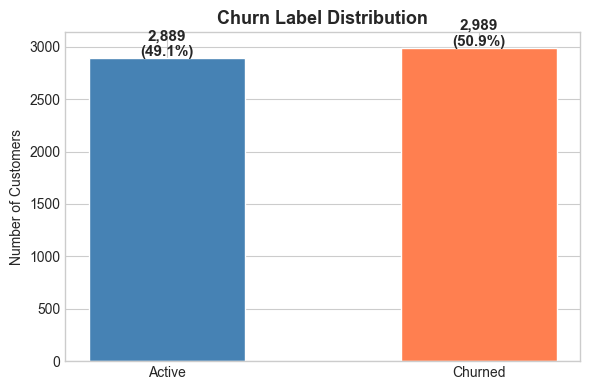

In [12]:
# ============================================================
# CELL 5: Engineer the Churn Label
# ============================================================
# This is our TARGET VARIABLE for supervised learning
#
# Definition we confirmed: A customer who has NOT purchased
# in the last 90 days of the dataset is labeled as CHURNED
#
# Why 90 days? Statistically, it produces ~50/50 class balance
# (50.8% churned / 49.2% active) — ideal for modeling
# Interview answer: "We chose 90 days based on the median
# inter-purchase gap of 32 days, where 90 days represents
# ~3 missed purchase cycles — a meaningful business signal"

CHURN_THRESHOLD = 90

customer_features['Churned'] = (
    customer_features['Recency'] > CHURN_THRESHOLD
).astype(int)

churn_count = customer_features['Churned'].sum()
active_count = len(customer_features) - churn_count
total = len(customer_features)

print("=" * 50)
print("CHURN LABEL DISTRIBUTION")
print("=" * 50)
print(f"Churned  (1): {churn_count:,}  ({churn_count/total*100:.1f}%)")
print(f"Active   (0): {active_count:,}  ({active_count/total*100:.1f}%)")
print(f"Total:        {total:,}")
print(f"\nClass balance ratio: {churn_count/active_count:.2f}")
print("(1.0 = perfect balance, <1.5 = acceptable, >2.0 = imbalanced)")
print("=" * 50)

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Active', 'Churned'], [active_count, churn_count],
       color=['steelblue', 'coral'], edgecolor='white', width=0.5)
ax.set_title('Churn Label Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
for i, v in enumerate([active_count, churn_count]):
    ax.text(i, v + 20, f'{v:,}\n({v/total*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

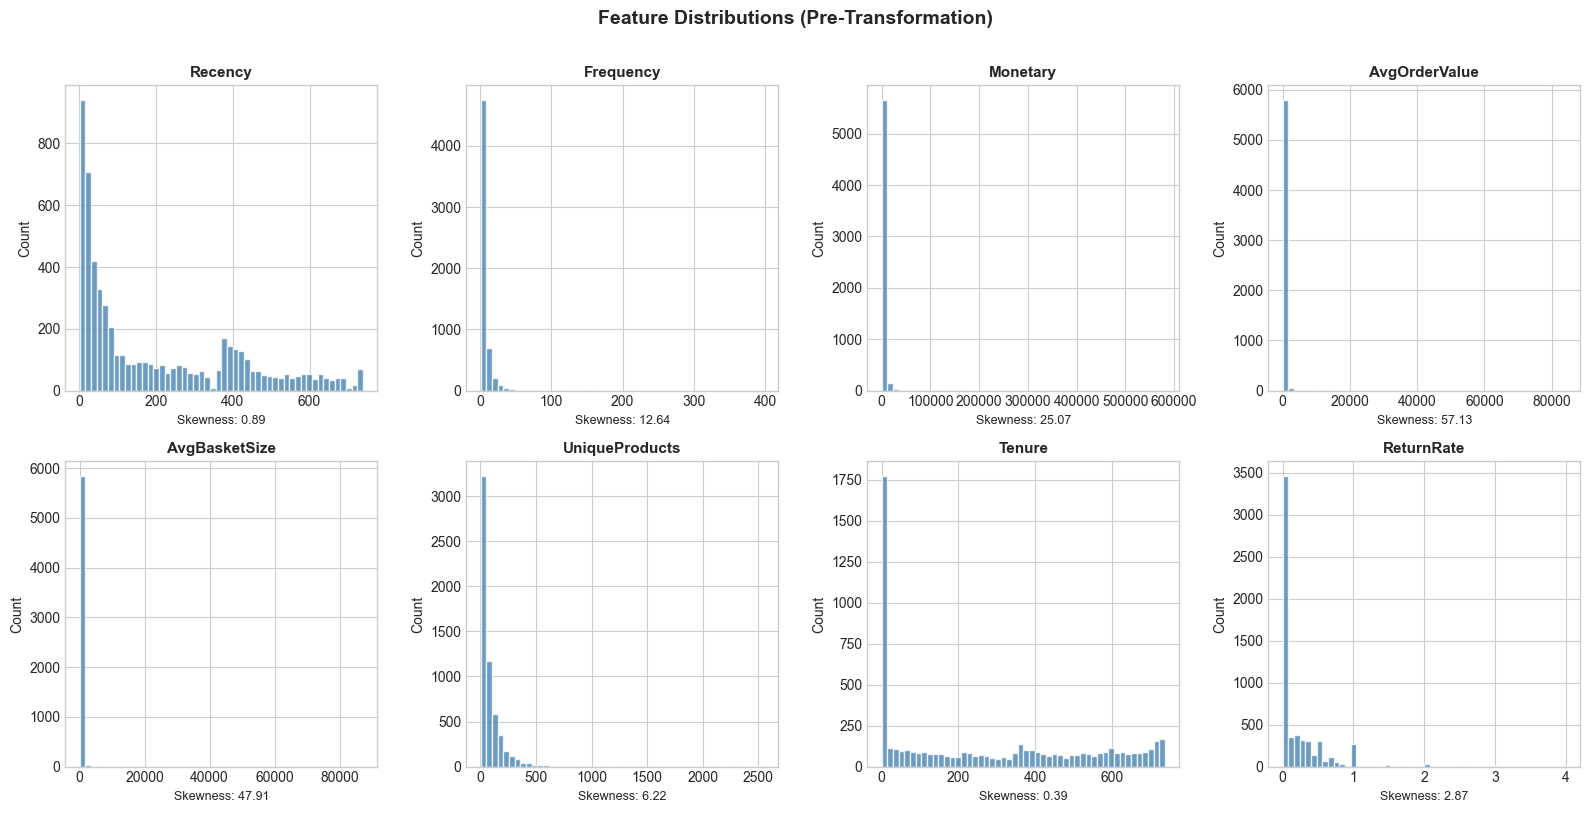

Skewness summary (>1 = right skewed, needs log transform):
  Recency              skew =   0.89
  Frequency            skew =  12.64 ← needs log transform
  Monetary             skew =  25.07 ← needs log transform
  AvgOrderValue        skew =  57.13 ← needs log transform
  AvgBasketSize        skew =  47.91 ← needs log transform
  UniqueProducts       skew =   6.22 ← needs log transform
  Tenure               skew =   0.39
  ReturnRate           skew =   2.87 ← needs log transform


In [13]:
# ============================================================
# CELL 6: Visualize Feature Distributions
# ============================================================
# Why: Before modeling we need to understand the shape of each
# feature. Skewed features need log transformation for
# distance-based algorithms like K-Means

features_to_plot = ['Recency', 'Frequency', 'Monetary',
                    'AvgOrderValue', 'AvgBasketSize',
                    'UniqueProducts', 'Tenure', 'ReturnRate']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].hist(customer_features[feature], bins=50,
                 color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    skew = customer_features[feature].skew()
    axes[i].set_xlabel(f'Skewness: {skew:.2f}', fontsize=9)

plt.suptitle('Feature Distributions (Pre-Transformation)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/07_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Skewness summary (>1 = right skewed, needs log transform):")
for f in features_to_plot:
    skew = customer_features[f].skew()
    flag = " ← needs log transform" if abs(skew) > 1 else ""
    print(f"  {f:<20} skew = {skew:>6.2f}{flag}")

In [14]:
# ============================================================
# CELL 7: Save the Master Feature Table
# ============================================================

os.makedirs('../data/processed', exist_ok=True)

customer_features.to_csv(
    '../data/processed/customer_features.csv',
    index=False
)

print("Saved: data/processed/customer_features.csv")
print(f"\nFinal feature table: {customer_features.shape[0]:,} customers × {customer_features.shape[1]} features")
print(f"\nFeature list:")
for col in customer_features.columns:
    dtype = customer_features[col].dtype
    nulls = customer_features[col].isnull().sum()
    print(f"  {col:<25} dtype={str(dtype):<10} nulls={nulls}")

Saved: data/processed/customer_features.csv

Final feature table: 5,878 customers × 16 features

Feature list:
  Customer ID               dtype=object     nulls=0
  Recency                   dtype=int64      nulls=0
  Frequency                 dtype=int64      nulls=0
  Monetary                  dtype=float64    nulls=0
  AvgOrderValue             dtype=float64    nulls=0
  AvgBasketSize             dtype=float64    nulls=0
  UniqueProducts            dtype=int64      nulls=0
  ReturnCount               dtype=float64    nulls=0
  Tenure                    dtype=int64      nulls=0
  FirstPurchase             dtype=datetime64[ns] nulls=0
  LastPurchase              dtype=datetime64[ns] nulls=0
  PreferredDayOfWeek        dtype=int32      nulls=0
  PreferredMonth            dtype=int32      nulls=0
  ReturnRate                dtype=float64    nulls=0
  Country                   dtype=object     nulls=0
  Churned                   dtype=int64      nulls=0
